In [1]:
import dataclasses
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

from lib.plots import set_axis
from lib.stats import fit_power_law

In [78]:
task_ids = {
    "control":     "task-1-control",
    "Δcohesin":    "task-2-delcohesin",
    "ac+":         "task-3-acetyl",
    "ac+Δcohesin": "task-4-acetyl_delcohesin",
}

@dataclasses.dataclass
class Metrics:
    files: list[str]
    config: dict
    site_msds: np.ndarray
    domain_rgs: np.ndarray
    separation_scores: np.ndarray
    mixing_scores: np.ndarray

conds_metrics = {}

for key, task_id in task_ids.items():
    with h5py.File(f"{task_id}/_outputs/metrics-nocen.h5", "r") as store:
        conds_metrics[key] = Metrics(
            files=[s.decode() for s in store["files"][()]],
            config=json.loads(store["config"][()]),
            site_msds=store["site_msds"][:, :, :],
            domain_rgs=store["domain_rgs"][:],
            separation_scores=store["separation_scores"][:],
            mixing_scores=(1 / store["separation_scores"][:]),
        )

In [42]:
@dataclasses.dataclass
class MSDAnalysis:
    lags: np.ndarray
    means: np.ndarray
    stds: np.ndarray
    alpha: float
    beta: float

In [43]:
reference_lag = 10

conds_msds = {}

for key, metrics in conds_metrics.items():
    config = metrics.config
    sampling_config = config["sampling"]
    phase_overrides = sampling_config["phases"][-1]
    phase_config = {**sampling_config, **phase_overrides}
    frame_interval = phase_config["timestep"] * phase_config["sampling_interval"]

    site_msds = metrics.site_msds[:, :reference_lag + 1, :]
    lags = np.arange(site_msds.shape[1]) * frame_interval
    msd_samples = einops.rearrange(site_msds, "r t s -> (r s) t")
    msd_mean = msd_samples.mean(axis=0)
    msd_std = msd_samples.std(axis=0)

    x = lags
    y = msd_mean
    alpha, beta = fit_power_law(x, y)

    conds_msds[key] = MSDAnalysis(
        lags=lags,
        means=msd_mean,
        stds=msd_std,
        alpha=alpha,
        beta=beta,
    )

In [44]:
for key, msd in conds_msds.items():
    print("{:12s} α={:.3g} Deff={:.3g}".format(key, msd.alpha, msd.beta))

control      α=0.527 Deff=12.7
Δcohesin     α=0.54 Deff=14.3
ac+          α=0.53 Deff=26.1
ac+Δcohesin  α=0.571 Deff=33


In [45]:
cond_colors = {
    "control":     "C:k",
    "Δcohesin":    "C:r",
    "ac+":         "C:y",
    "ac+Δcohesin": "C:m",
}

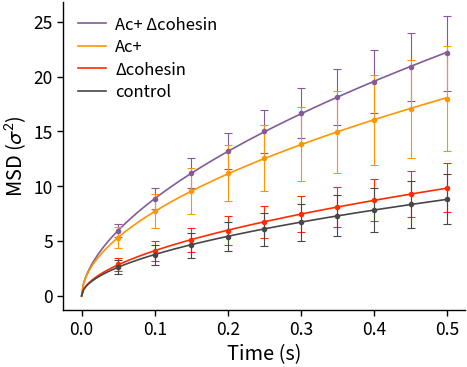

In [48]:
fig, ax = plt.subplots(figsize=(2.4, 1.9))

labels = {
    "control":     "control",
    "Δcohesin":    "Δcohesin",
    "ac+":         "Ac+",
    "ac+Δcohesin": "Ac+ Δcohesin",
}

for key, msd in reversed(conds_msds.items()):
    x = msd.lags[1:]
    y = msd.means[1:]
    y_err = msd.stds[1:]
    ax.errorbar(
        x, y, y_err,
        color=cond_colors[key],
        marker="o",
        markersize=1,
        linewidth=0,
        elinewidth=0.4,
        capsize=1.3,
        capthick=0.4,
        zorder=2,
    )

    x = np.linspace(msd.lags[0], msd.lags[-1], num=200)
    y = x**msd.alpha * msd.beta
    ax.plot(x, y, lw=0.6, color=cond_colors[key], label=labels[key])

    # x = msd.lags[-1]
    # y = x**msd.alpha * msd.beta
    # s = f"  α = {msd.alpha:.2f}"
    # ax.text(x, y, s, ha="left", va="center")

ax.legend(frameon=True)
ax.set_xticks(np.arange(0, 0.51, 0.1))
ax.set_xlabel(r"Time (s)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")

set_axis(ax, "left bottom")

for ext in ["svg", "png"]:
    fig.savefig(f"_figs/msd_curve.{ext}", transparent=True)

pass

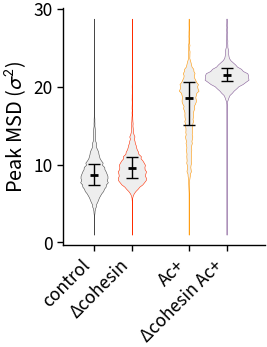

In [74]:
msd_bins = np.linspace(1, 29, num=101)
density_scale = 0.7

x_positions = {
    "control":     0.8,
    "Δcohesin":    1.2,
    "ac+":         1.8,
    "ac+Δcohesin": 2.2,
}

labels = {
    "control":     "control",
    "Δcohesin":    "Δcohesin",
    "ac+":         "Ac+",
    "ac+Δcohesin": "Δcohesin Ac+",
}


fig, ax = plt.subplots(figsize=(1.4, 1.8))

for key, metrics in conds_metrics.items():
    color = cond_colors[key]
    msds = metrics.site_msds[:, reference_lag, :].ravel()

    x_position = x_positions[key]
    values = msds

    density, _ = np.histogram(
        values,
        bins=msd_bins,
        density=True,
    )
    ax.fill_betweenx(
        msd_bins[:-1],
        x_position + density * density_scale,
        x_position - density * density_scale,
        edgecolor=color,
        facecolor="#eee",
        linewidth=0.2,
        zorder=2,
    )

    mid = np.median(values)
    upper = np.percentile(values, q=75)
    lower = np.percentile(values, q=25)
    x = [x_position]
    y = [mid]
    y_err = ([mid - lower], [upper - mid])
    ax.errorbar(
        x,
        y,
        y_err,
        color="k",
        marker="_",
        markersize=3,
        elinewidth=0.5,
        capsize=2.0,
        capthick=0.5,
    )

ax.margins(x=0.1)

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(list(labels.values()), rotation=45, ha="right")
ax.set_ylabel(r"Peak MSD ($ \sigma^2 $)")

set_axis(ax, "left bottom")

for ext in ["svg", "png"]:
    fig.savefig(f"_figs/max_msd.{ext}", transparent=True)

pass

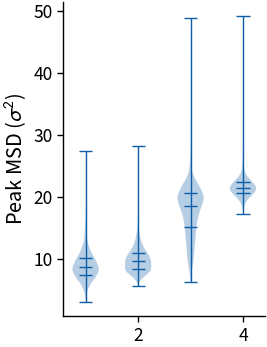

In [92]:
fig, ax = plt.subplots(figsize=(1.4, 1.8))

ax.violinplot(
    [
        metrics.site_msds[:, reference_lag, :].ravel()
        for key, metrics in conds_metrics.items()
    ],
    showmedians=True,
    quantiles=[[0.25, 0.75]] * 4,
)

ax.set_ylabel(r"Peak MSD ($ \sigma^2 $)")

set_axis(ax, "left bottom")

pass

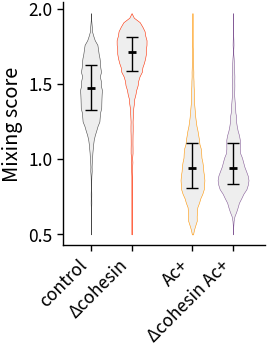

In [85]:
score_bins = np.linspace(0.5, 2, num=51)
density_scale = 0.06

x_positions = {
    "control":     0.8,
    "Δcohesin":    1.2,
    "ac+":         1.8,
    "ac+Δcohesin": 2.2,
}

labels = {
    "control":     "control",
    "Δcohesin":    "Δcohesin",
    "ac+":         "Ac+",
    "ac+Δcohesin": "Δcohesin Ac+",
}

fig, ax = plt.subplots(figsize=(1.4, 1.8))

for key, metrics in conds_metrics.items():
    color = cond_colors[key]
    msds = metrics.mixing_scores.ravel()

    x_position = x_positions[key]
    values = msds

    density, _ = np.histogram(
        values,
        bins=score_bins,
        density=True,
    )
    ax.fill_betweenx(
        score_bins[:-1],
        x_position + density * density_scale,
        x_position - density * density_scale,
        edgecolor=color,
        facecolor="#eee",
        linewidth=0.2,
        zorder=2,
    )

    mid = np.median(values)
    upper = np.percentile(values, q=75)
    lower = np.percentile(values, q=25)
    x = [x_position]
    y = [mid]
    y_err = ([mid - lower], [upper - mid])
    ax.errorbar(
        x,
        y,
        y_err,
        color="k",
        marker="_",
        markersize=3,
        elinewidth=0.5,
        capsize=2.0,
        capthick=0.5,
    )

ax.margins(x=0.1)

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(list(labels.values()), rotation=45, ha="right")
ax.set_ylabel("Mixing score")

set_axis(ax, "left bottom")

for ext in ["svg", "png"]:
    fig.savefig(f"_figs/mixing_score.{ext}", transparent=True)

pass

In [79]:
mixing_scores = {
    key: metrics.mixing_scores.ravel()
    for key, metrics in conds_metrics.items()
}

test = scipy.stats.ttest_rel(
    mixing_scores["control"],
    mixing_scores["Δcohesin"],
)
print(test)

TtestResult(statistic=-97.3497459356609, pvalue=0.0, df=20019)
